#PRUEBA

### Configuración e instalación

In [1]:
!pip install pyBKT scikit-learn -q

In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pyBKT.models import Model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Parche para pyBKT en Python 3.12 (Evita error de float en random.randint)
_original_randint = random.randint
random.randint = lambda a, b: _original_randint(int(a), int(b))

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

##Función Principal de Entrenamiento y Evaluación

In [6]:
def evaluar_cluster_pybkt(train_df, test_df, rebkt_df, cluster_id, dataset_name):
    """
    Filtra los datos por clúster, entrena el modelo PyBKT original, calcula métricas,
    gráfica la matriz de confusión y guarda los archivos CSV alineados.
    """
    print(f"INICIANDO EVALUACIÓN: {dataset_name} - CLUSTER {cluster_id}")

    # 1. Filtrar datos por cluster
    train_c = train_df[train_df['cluster'] == cluster_id].drop(columns=['cluster']).copy()
    test_c = test_df[test_df['cluster'] == cluster_id].drop(columns=['cluster']).copy()
    rebkt_c = rebkt_df[rebkt_df['cluster'] == cluster_id].drop(columns=['cluster']).copy()

    # 2. Entrenar Modelo
    print("Entrenando modelo PyBKT base")
    model = Model(seed=42, num_fits=1, parallel=False)
    model.fit(data=train_c)

    # 3. Generar Predicciones
    print("Generando predicciones sobre Test")
    preds = model.predict(data=test_c)

    # 4. Cálculo de Métricas Clásicas
    y_true = test_c['correct']
    y_pred_bin = (preds['correct_predictions'] >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true, y_pred_bin)
    prec = precision_score(y_true, y_pred_bin, zero_division=0)
    rec = recall_score(y_true, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)

    eval_simple = model.evaluate(data=test_c, metric=['auc', 'rmse'])

    print(f"\nResultados de las métricas:")
    print(f"  - Precisión:     {prec:.4f}")
    print(f"  - Sensibilidad:  {rec:.4f} (Recall)")
    print(f"  - Especificidad: {spec:.4f}")
    print(f"  - Accuracy:      {acc:.4f}")
    print(f"  - F1-Score:      {f1:.4f}")
    print(f"  - RMSE:          {eval_simple[1]:.4f}")
    print(f"  - AUC:           {eval_simple[0]:.4f}")


    # 5. Generar y Guardar Matriz de Confusión
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', cbar=False, ax=ax, annot_kws={"size": 12})
    ax.set_title(f"PyBKT Matriz - {dataset_name} (Cluster {cluster_id})", pad=15)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    plt.tight_layout()

    img_name = f"cm_pybkt_{dataset_name.replace(' ', '')}_C{cluster_id}.png"
    plt.savefig(img_name, dpi=300)
    plt.show()

    # 6. Guardar predicciones de PyBKT
    file_preds = f"predicPyBKT_{dataset_name.replace(' ', '')}_c{cluster_id}.csv"
    preds.to_csv(file_preds, index=False)

    # 7. Alinear y Guardar RE-BKT para la prueba de DeLong
    df_re = rebkt_c.reindex(preds.index)
    if not (preds['correct'] == df_re['correct']).all():
        raise AssertionError("CRÍTICO: Las realidades entre PyBKT y RE-BKT no coinciden.")

    file_re = f"Re{dataset_name.replace(' ', '')}_C{cluster_id}.csv"
    df_re.to_csv(file_re, index=False)

    print(f"Archivos guardados: {file_preds} y {file_re}")

    return preds, df_re

##Ejecución para ASSISTments 2012 (Dataset 1)

Cargando archivos del Dataset 1
INICIANDO EVALUACIÓN: D1 - CLUSTER 0
Entrenando modelo PyBKT base
Generando predicciones sobre Test

Resultados de las métricas:
  - Precisión:     0.6586
  - Sensibilidad:  0.8450 (Recall)
  - Especificidad: 0.3760
  - Accuracy:      0.6516
  - F1-Score:      0.7402
  - RMSE:          0.4685
  - AUC:           0.6732


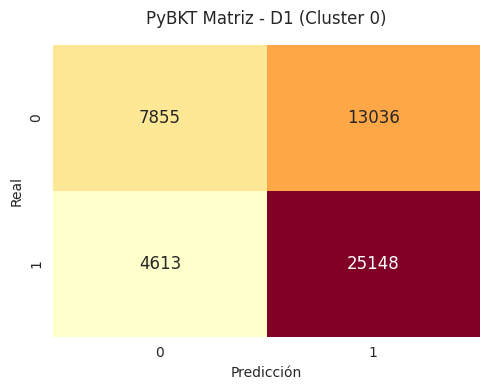

Archivos guardados: predicPyBKT_D1_c0.csv y ReD1_C0.csv
INICIANDO EVALUACIÓN: D1 - CLUSTER 1
Entrenando modelo PyBKT base
Generando predicciones sobre Test

Resultados de las métricas:
  - Precisión:     0.7337
  - Sensibilidad:  0.9632 (Recall)
  - Especificidad: 0.1325
  - Accuracy:      0.7246
  - F1-Score:      0.8329
  - RMSE:          0.4346
  - AUC:           0.6699


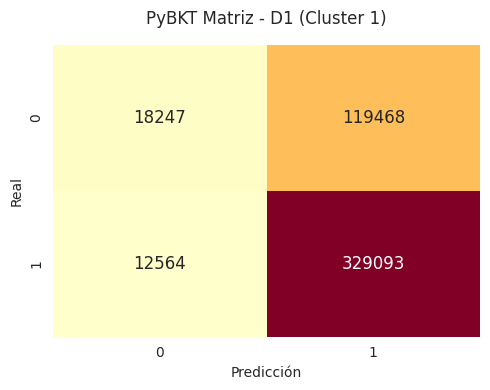

Archivos guardados: predicPyBKT_D1_c1.csv y ReD1_C1.csv


In [9]:
# PROCESAR DATASET 1 (ASSISTments 2012)
cols_required = ['user_id', 'skill', 'correct', 'cluster']

print("Cargando archivos del Dataset 1")
train_12 = pd.read_csv('train_df.csv', encoding='latin-1', low_memory=False)[cols_required]
test_12 = pd.read_csv('test_df.csv', encoding='latin-1', low_memory=False)[cols_required]
rebkt_12 = pd.read_csv('df_final.csv', encoding='latin-1', low_memory=False)

# Estandarizar nombre de columna 'skill'
train_12.rename(columns={'skill': 'skill_name'}, inplace=True)
test_12.rename(columns={'skill': 'skill_name'}, inplace=True)
rebkt_12.rename(columns={'skill': 'skill_name'}, inplace=True)

# Ejecutar y generar todo para Cluster 0 y 1 automáticamente
preds_d1_c0, re_d1_c0 = evaluar_cluster_pybkt(train_12, test_12, rebkt_12, cluster_id=0, dataset_name="D1")
preds_d1_c1, re_d1_c1 = evaluar_cluster_pybkt(train_12, test_12, rebkt_12, cluster_id=1, dataset_name="D1")

##Ejecución para ASSISTments 2017 (Dataset 2)

Cargando archivos del Dataset 2
INICIANDO EVALUACIÓN: D2 - CLUSTER 0
Entrenando modelo PyBKT base
Generando predicciones sobre Test

Resultados de las métricas:
  - Precisión:     0.5991
  - Sensibilidad:  0.4077 (Recall)
  - Especificidad: 0.7921
  - Accuracy:      0.6259
  - F1-Score:      0.4852
  - RMSE:          0.4789
  - AUC:           0.6469


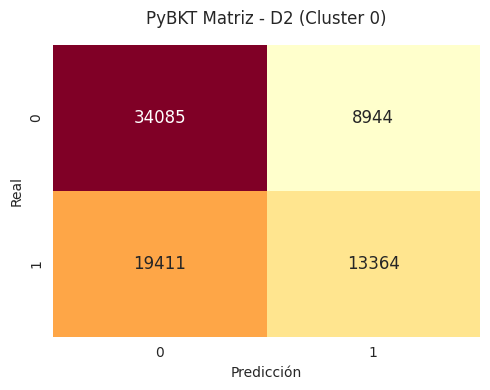

Archivos guardados: predicPyBKT_D2_c0.csv y ReD2_C0.csv
INICIANDO EVALUACIÓN: D2 - CLUSTER 1
Entrenando modelo PyBKT base
Generando predicciones sobre Test

Resultados de las métricas:
  - Precisión:     0.5531
  - Sensibilidad:  0.1135 (Recall)
  - Especificidad: 0.9572
  - Accuracy:      0.6884
  - F1-Score:      0.1883
  - RMSE:          0.4563
  - AUC:           0.6168


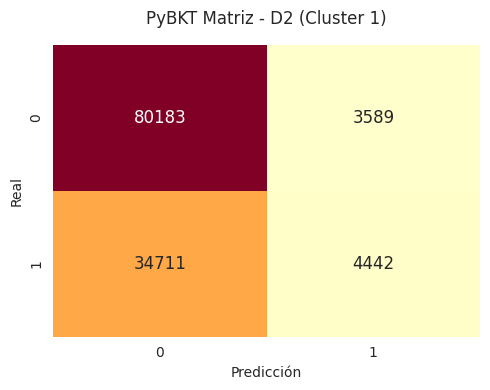

Archivos guardados: predicPyBKT_D2_c1.csv y ReD2_C1.csv


In [10]:
# PROCESAR DATASET 2 (ASSISTments 2017)
print("Cargando archivos del Dataset 2")
train_17 = pd.read_csv('train_df_2017_31_03.csv', encoding='latin-1', low_memory=False)[cols_required]
test_17 = pd.read_csv('test_df_2017_31_03.csv', encoding='latin-1', low_memory=False)[cols_required]
rebkt_17 = pd.read_csv('df_final2.csv', encoding='latin-1', low_memory=False)

# Estandarizar nombre de columna 'skill'
train_17.rename(columns={'skill': 'skill_name'}, inplace=True)
test_17.rename(columns={'skill': 'skill_name'}, inplace=True)
rebkt_17.rename(columns={'skill': 'skill_name'}, inplace=True)

# Ejecutar y generar todo para Cluster 0 y 1 automáticamente
preds_d2_c0, re_d2_c0 = evaluar_cluster_pybkt(train_17, test_17, rebkt_17, cluster_id=0, dataset_name="D2")
preds_d2_c1, re_d2_c1 = evaluar_cluster_pybkt(train_17, test_17, rebkt_17, cluster_id=1, dataset_name="D2")